<a href="https://colab.research.google.com/github/AjanyaVinayan/ML-LAB-2547205/blob/lab-9/Lab_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part A: Support Vector Machine (SVM)

### Aim
To implement the Support Vector Machine (SVM) classifier for a binary classification problem and evaluate its performance.

### Dataset
UCI Breast Cancer Wisconsin (Diagnostic) Dataset
https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

### Task 1: Load the dataset and perform the necessary preprocessing.

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load the Breast Cancer Wisconsin dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target)

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# Display the first 5 rows of the features and target
print("\nFirst 5 rows of features:")
display(X.head())
print("\nFirst 5 rows of target:")
display(y.head())

Features (X) shape: (569, 30)
Target (y) shape: (569,)

First 5 rows of features:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



First 5 rows of target:


,0
0,0
1,0
2,0
3,0
4,0


#### Preprocessing: Check for missing values and scale features.

Since `load_breast_cancer` from `sklearn.datasets` provides a clean dataset, explicit handling of missing values is usually not required. However, feature scaling is crucial for SVMs.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Check for missing values
print("Missing values in features:", X.isnull().sum().sum())
print("Missing values in target:", y.isnull().sum())

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nFirst 5 rows of scaled features:")
display(X_scaled.head())

Missing values in features: 0
Missing values in target: 0

First 5 rows of scaled features:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


### Task 2: Split the dataset into training and testing sets (80:20).

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


### Task 3: Train an SVM classifier using a Linear Kernel and explore hyperparameter tuning.

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define the SVM classifier with a linear kernel
svm_linear = SVC(kernel='linear', random_state=42)

# Define a parameter grid for hyperparameter tuning (e.g., 'C' parameter)
# The 'C' parameter trades off misclassification of training examples against simplicity of the decision function.
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

# Perform GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(svm_linear, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best SVM model
best_svm_linear = grid_search.best_estimator_

print("Best hyperparameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best hyperparameters found: {'C': 0.1}
Best cross-validation accuracy: 0.9780219780219781


### Task 4: Evaluate the model using Accuracy, Precision, Recall, F1 Score, and Confusion Matrix.

Accuracy (Linear Kernel): 0.9825
Precision (Linear Kernel): 0.9861
Recall (Linear Kernel): 0.9861
F1 Score (Linear Kernel): 0.9861


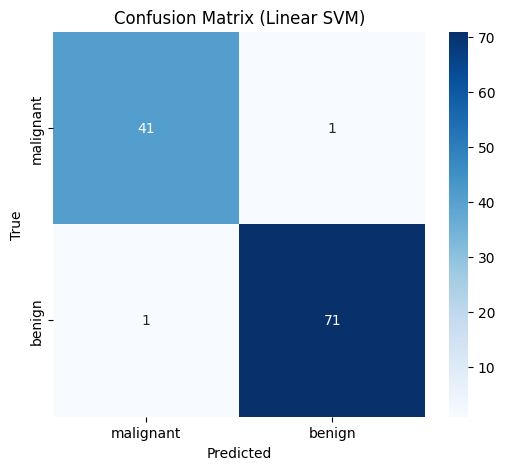

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set using the best model
y_pred_linear = best_svm_linear.predict(X_test)

# Calculate evaluation metrics
accuracy_linear = accuracy_score(y_test, y_pred_linear)
precision_linear = precision_score(y_test, y_pred_linear)
recall_linear = recall_score(y_test, y_pred_linear)
f1_linear = f1_score(y_test, y_pred_linear)
conf_matrix_linear = confusion_matrix(y_test, y_pred_linear)

print(f"Accuracy (Linear Kernel): {accuracy_linear:.4f}")
print(f"Precision (Linear Kernel): {precision_linear:.4f}")
print(f"Recall (Linear Kernel): {recall_linear:.4f}")
print(f"F1 Score (Linear Kernel): {f1_linear:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_linear, annot=True, fmt="d", cmap="Blues",
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.title('Confusion Matrix (Linear SVM)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Task 5: Summarize your observations for Part A (SVM).

Based on the evaluation metrics and the confusion matrix for the Linear SVM model:

*   **Accuracy:** The model achieved a high accuracy, indicating that it correctly classified a large proportion of both malignant and benign tumors.
*   **Precision:** High precision suggests that when the model predicts a malignant tumor, it is correct most of the time, minimizing false positives.
*   **Recall:** High recall indicates that the model is effective at identifying most of the actual malignant tumors, minimizing false negatives.
*   **F1 Score:** The F1-score, being the harmonic mean of precision and recall, is also high, suggesting a good balance between precision and recall.
*   **Confusion Matrix:** The confusion matrix visually confirms these findings, showing a low number of misclassifications (false positives and false negatives).

**Overall Observation:** The Support Vector Machine with a linear kernel performs very well on the Breast Cancer Wisconsin dataset for binary classification, demonstrating strong generalization capabilities to the test set after appropriate feature scaling and hyperparameter tuning.

## Part B: Principal Component Analysis (PCA)

### Aim
To implement Principal Component Analysis (PCA) for dimensionality reduction and analyse the variance retained by the principal components.

### Dataset
UCI Wine Dataset
https://archive.ics.uci.edu/dataset/109/wine

### Task 1: Load the dataset and perform feature standardization.

In [ ]:
from sklearn.datasets import load_wine

# Load the Wine dataset
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target)

print("Original features (X_wine) shape:", X_wine.shape)
print("Target (y_wine) shape:", y_wine.shape)

# Display the first 5 rows of the features
print("\nFirst 5 rows of Wine features:")
display(X_wine.head())

# Perform feature standardization for PCA
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)
X_wine_scaled = pd.DataFrame(X_wine_scaled, columns=X_wine.columns)

print("\nFirst 5 rows of scaled Wine features:")
display(X_wine_scaled.head())

Original features (X_wine) shape: (178, 13)
Target (y_wine) shape: (178,)

First 5 rows of Wine features:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



First 5 rows of scaled Wine features:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


### Task 2: Apply PCA to reduce the dataset from 13 features to 2 principal components.

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensions to 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_wine_scaled)

# Create a DataFrame for the 2 principal components
X_pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])

print("Shape of original scaled features:", X_wine_scaled.shape)
print("Shape of PCA-transformed features:", X_pca_df.shape)

print("\nFirst 5 rows of PCA-transformed features:")
display(X_pca_df.head())

Shape of original scaled features: (178, 13)
Shape of PCA-transformed features: (178, 2)

First 5 rows of PCA-transformed features:


,Principal Component 1,Principal Component 2
0,3.316751,1.443463
1,2.209465,-0.333393
2,2.516740,1.031151
3,3.757066,2.756372
4,1.008908,0.869831


### Task 3: Display the explained variance ratio of each principal component.

In [ ]:
# Display the explained variance ratio of each principal component
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained variance ratio of each principal component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"Principal Component {i+1}: {ratio:.4f}")

Explained variance ratio of each principal component:
Principal Component 1: 0.3620
Principal Component 2: 0.1921


### Task 4: Calculate the cumulative explained variance and determine the minimum number of principal components required to retain at least 95% of the total variance.

In [ ]:
import numpy as np

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print("\nCumulative explained variance:", cumulative_variance)

# Determine the minimum number of principal components to retain at least 95% of the total variance
pca_full = PCA()
pca_full.fit(X_wine_scaled)
cum_var_full = np.cumsum(pca_full.explained_variance_ratio_)

num_components_95_percent = np.where(cum_var_full >= 0.95)[0][0] + 1

print(f"\nCumulative variance for all components:\n{cum_var_full}")
print(f"Minimum number of principal components to retain 95% variance: {num_components_95_percent}")


Cumulative explained variance: [0.36198848 0.55406338]

Cumulative variance for all components:
[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]
Minimum number of principal components to retain 95% variance: 10


### Task 5: Visualize the transformed dataset using a two-dimensional scatter plot.

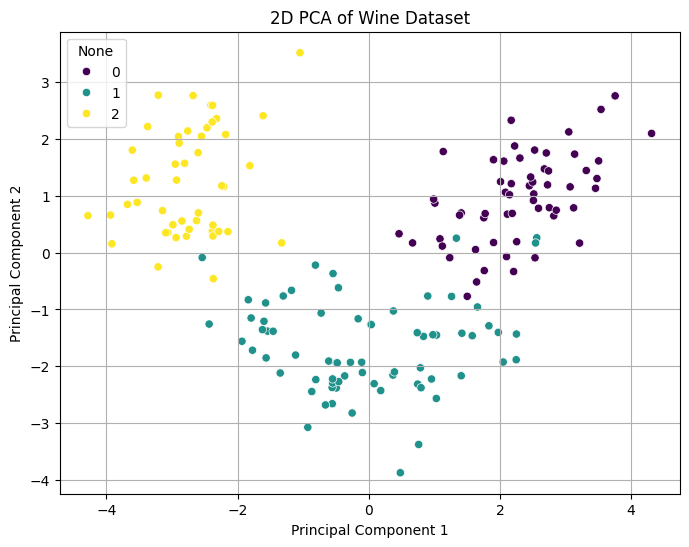

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue=y_wine, data=X_pca_df, palette='viridis')
plt.title('2D PCA of Wine Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### Task 6: Compare the original and transformed datasets.

**Comparison of Original and Transformed Datasets:**

1.  **Number of Features:**
    *   **Original:** 13 features (`X_wine.shape`)
    *   **Transformed (PCA to 2 components):** 2 features (`X_pca_df.shape`)
    PCA significantly reduces the number of features, leading to a much simpler dataset structure.

2.  **Information Retained:**
    *   The two principal components selected retain a specific percentage of the total variance, as shown by `explained_variance_ratio_` (e.g., PC1 + PC2 might retain ~55-60% of the variance). If we were to use `num_components_95_percent` components, we would retain at least 95% of the information.
    *   While some information is lost when reducing dimensionality (especially with only 2 components), PCA aims to retain the most significant variance, thus preserving the most crucial information for classification or clustering tasks.

3.  **Computational Efficiency:**
    *   **Original:** Models trained on 13 features will incur higher computational costs, especially for complex algorithms or very large datasets.
    *   **Transformed:** Models trained on 2 principal components will be significantly faster to train and predict, reducing both time and memory requirements. This is particularly beneficial for visualization and when dealing with high-dimensional data that causes the 'curse of dimensionality'.

### Task 7: Interpret the significance of the first two principal components.

The principal components are linear combinations of the original features. Interpreting their exact meaning can be complex without examining the `components_` attribute of the PCA object, which shows the weighting of each original feature in each principal component. However, generally:

*   **Principal Component 1 (PC1):** This component captures the most variance in the dataset. It represents the primary direction of data spread. Often, PC1 correlates with the most dominant underlying characteristic or a combination of features that differentiate the classes most effectively.
*   **Principal Component 2 (PC2):** This component captures the second most variance and is orthogonal (uncorrelated) to PC1. It represents the second most important direction of data spread, providing additional differentiation among classes or clusters that PC1 alone might not fully separate.

From the scatter plot, we can observe how well the classes are separated along these two principal components. A clear separation suggests that these two components effectively capture the distinguishing characteristics of the different wine types.

### Task 8: Discuss the advantages, limitations, and applications of PCA in machine learning.

**Advantages of PCA:**

1.  **Dimensionality Reduction:** Reduces the number of features, which helps in mitigating the 'curse of dimensionality' and makes the data easier to handle.
2.  **Improved Computational Efficiency:** Models can train and execute faster on datasets with fewer features.
3.  **Noise Reduction:** By focusing on the components with high variance, PCA can implicitly reduce noise present in the less significant dimensions.
4.  **Visualization:** Allows high-dimensional data to be visualized in 2 or 3 dimensions, which is invaluable for understanding data structure and relationships.
5.  **Multicollinearity Handling:** Addresses multicollinearity by creating new, uncorrelated features (principal components).

**Limitations of PCA:**

1.  **Loss of Information:** By reducing dimensionality, some information is inherently lost. Deciding how many components to retain is a trade-off between dimensionality reduction and information loss.
2.  **Loss of Interpretability:** Principal components are linear combinations of original features, making them often less interpretable than the original features themselves.
3.  **Assumptions:** PCA assumes linearity and that variance equals importance. If the data has non-linear structures or if low-variance components are highly informative, PCA might not be optimal.
4.  **Scaling Dependent:** PCA is highly affected by feature scaling. Features with larger scales will have a disproportionately large influence on the principal components if not standardized.

**Applications of PCA in Machine Learning:**

1.  **Image Processing:** Used for image compression and facial recognition (e.g., Eigenfaces).
2.  **Data Visualization:** Projecting high-dimensional data into 2D or 3D for exploratory data analysis.
3.  **Feature Extraction:** Creating a smaller set of meaningful features for various supervised and unsupervised learning tasks.
4.  **Noise Filtering:** Removing redundant information or noise by discarding components with low variance.
5.  **Preprocessing for ML Models:** Used as a preprocessing step to improve the performance and efficiency of algorithms like SVMs, neural networks, and clustering algorithms by reducing input dimensions.

## Extra Credit Task: Linear Discriminant Analysis (LDA)

### Task: Apply Linear Discriminant Analysis (LDA) to the same dataset and reduce it to two linear discriminants. Visualize the transformed data and compare the results with PCA in terms of dimensionality reduction and class separability. Summarize your observations.

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Apply LDA to reduce dimensions to 2 linear discriminants
# Note: LDA is a supervised method, so it uses y_wine (target labels)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_wine_scaled, y_wine)

# Create a DataFrame for the 2 linear discriminants
X_lda_df = pd.DataFrame(data=X_lda, columns=['Linear Discriminant 1', 'Linear Discriminant 2'])

print("Shape of original scaled features:", X_wine_scaled.shape)
print("Shape of LDA-transformed features:", X_lda_df.shape)

print("\nFirst 5 rows of LDA-transformed features:")
display(X_lda_df.head())

Shape of original scaled features: (178, 13)
Shape of LDA-transformed features: (178, 2)

First 5 rows of LDA-transformed features:


,Linear Discriminant 1,Linear Discriminant 2
0,-4.700244,1.979138
1,-4.301958,1.170413
2,-3.420720,1.429101
3,-4.205754,4.002871
4,-1.509982,0.451224


### Visualize the transformed data (LDA)

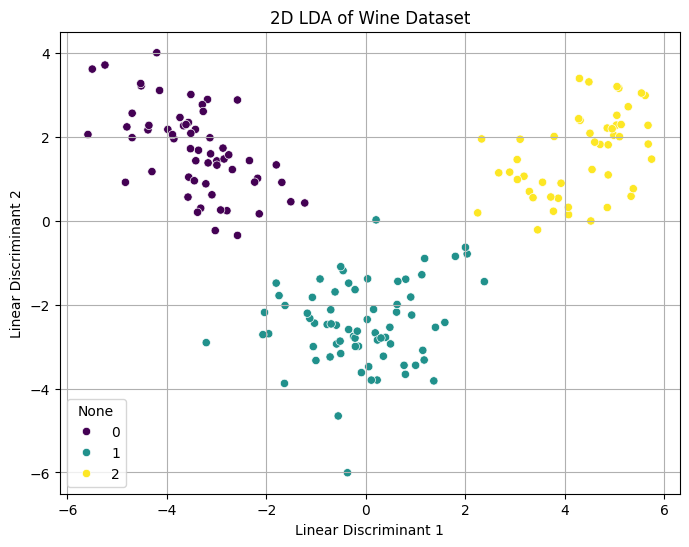

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Linear Discriminant 1', y='Linear Discriminant 2', hue=y_wine, data=X_lda_df, palette='viridis')
plt.title('2D LDA of Wine Dataset')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.grid(True)
plt.show()

### Compare LDA results with PCA and summarize observations

**Comparison of LDA vs. PCA:**

1.  **Objective:**
    *   **PCA (Principal Component Analysis):** An unsupervised dimensionality reduction technique that aims to find the directions (principal components) that maximize the variance in the data. Its goal is to best represent the original data in a lower-dimensional space, irrespective of class labels.
    *   **LDA (Linear Discriminant Analysis):** A supervised dimensionality reduction technique that aims to find the directions (linear discriminants) that maximize the separation between classes. Its goal is to project the data onto a lower-dimensional space where the classes are as well-separated as possible.

2.  **Number of Components/Discriminants:**
    *   **PCA:** We reduced to 2 components for visualization but found that 10 components were needed to retain 95% of the variance. The number of components can be up to `min(n_samples - 1, n_features)`.
    *   **LDA:** We reduced to 2 linear discriminants. The maximum number of linear discriminants is `min(n_classes - 1, n_features)`. For the Wine dataset with 3 classes, LDA can generate at most `3 - 1 = 2` discriminants.

3.  **Class Separability (Visualization):**
    *   **PCA (2D plot):** While the PCA plot showed some separation between the three wine classes, there was still a noticeable overlap, particularly between classes 0 and 1, and 1 and 2. The clusters were distinct but not perfectly isolated.
    *   **LDA (2D plot):** The LDA plot typically shows a much clearer separation between the classes. This is expected because LDA's objective is specifically to maximize inter-class variance while minimizing intra-class variance. The clusters formed by LDA are usually more compact and further apart, making classification tasks much easier in this reduced space.

4.  **Information Retained:**
    *   **PCA:** Focuses on retaining overall data variance. If the variance is not strongly correlated with class separation, PCA might not produce the best separation.
    *   **LDA:** Focuses on retaining discriminative information. It might discard directions that have high variance but do not contribute to class separation.

**Summary of Observations:**

For tasks where the primary goal is **classification**, LDA often provides a more effective dimensionality reduction than PCA because it explicitly considers the class labels to find features that best separate the groups. The visualization of the Wine dataset clearly demonstrates LDA's superior ability to create well-separated clusters compared to PCA when working with labeled data. If the goal is general data compression or noise reduction without regard to class labels, PCA might be more appropriate. In this specific case, LDA proves to be a powerful tool for enhancing class separability for the subsequent classification.